# RECAP — distributional value + advantage conditioning walkthrough

Manual exploration of the RECAP training recipe used by π*₀.₆:

1. **Distributional value head** (C51) learns a categorical distribution over return bins.
2. **Advantage = empirical return − value baseline** is bucketized and embedded as a conditioning token.
3. A policy trained to BC-on-experience conditioned on this token learns to reproduce above-average behavior when given a high advantage token at deployment.

Paper: `papers/2025-11-17_pistar06_vla-learns-from-experience.pdf`

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from pi_stack.training.recap import (
    AdvantageConditioner,
    DistributionalValueHead,
    RECAPConfig,
    RECAPTrainer,
)

torch.manual_seed(0)
device = 'mps' if torch.backends.mps.is_available() else 'cpu'

## 1. C51 head learns a known distribution

Set up a problem where the true return distribution at each 'state' is a known mixture. Train the C51 head with the Bellman projection and watch it converge.

In [2]:
cfg = RECAPConfig(advantage_bins=51, v_min=-3.0, v_max=3.0, target_update_period=100)
head = DistributionalValueHead(feature_dim=4, config=cfg)

# Generate states + their *true* terminal rewards (proxy for ground-truth return).
# Two clusters: one at +1, one at -1, with state features encoding cluster membership.
def synth_batch(B=128):
    cluster = torch.randint(0, 2, (B,))
    feats = torch.where(
        cluster.unsqueeze(-1) == 0,
        torch.tensor([1.0, 0.0, 0.0, 0.0]),
        torch.tensor([0.0, 1.0, 0.0, 0.0]),
    ) + 0.1 * torch.randn(B, 4)
    rewards = torch.where(cluster == 0, 1.0, -1.0)
    return feats, rewards

In [3]:
opt = torch.optim.Adam(head.parameters(), lr=3e-3)
history = {'loss': [], 'mean_v_plus': [], 'mean_v_minus': []}
for step in range(800):
    feats, rewards = synth_batch(B=128)
    next_feats = feats   # terminal — doesn't matter
    dones = torch.ones(feats.size(0))
    target = head.bellman_projection(rewards, next_feats, dones)
    loss = head.cross_entropy_loss(feats, target)
    opt.zero_grad(); loss.backward(); opt.step()
    if step % cfg.target_update_period == 0:
        head.sync_target()
    if step % 20 == 0:
        with torch.no_grad():
            v = head.value(feats)
            mask = (rewards > 0)
            history['loss'].append(loss.item())
            history['mean_v_plus'].append(v[mask].mean().item())
            history['mean_v_minus'].append(v[~mask].mean().item())

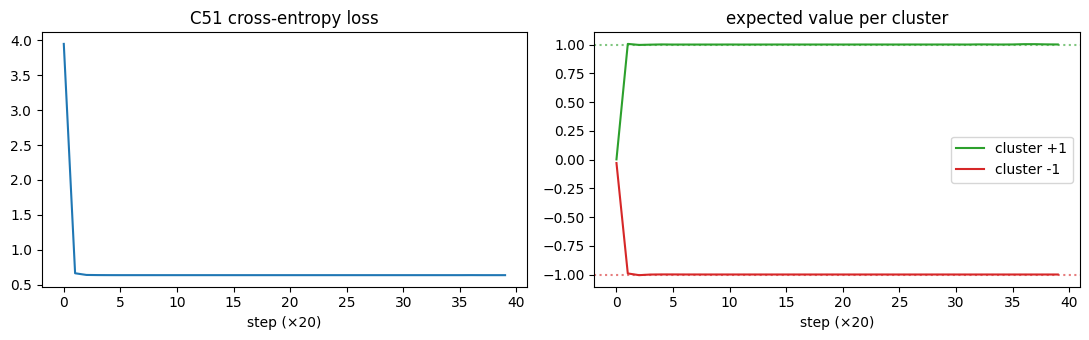

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(history['loss']); axes[0].set(title='C51 cross-entropy loss', xlabel='step (×20)')
axes[1].plot(history['mean_v_plus'],  label='cluster +1', color='tab:green')
axes[1].plot(history['mean_v_minus'], label='cluster -1', color='tab:red')
axes[1].axhline(+1, color='tab:green', ls=':', alpha=0.6)
axes[1].axhline(-1, color='tab:red',   ls=':', alpha=0.6)
axes[1].set(title='expected value per cluster', xlabel='step (×20)'); axes[1].legend()
fig.tight_layout()

## 2. Inspecting the learned distribution

For a sample from each cluster, plot the categorical probability mass over the return support.

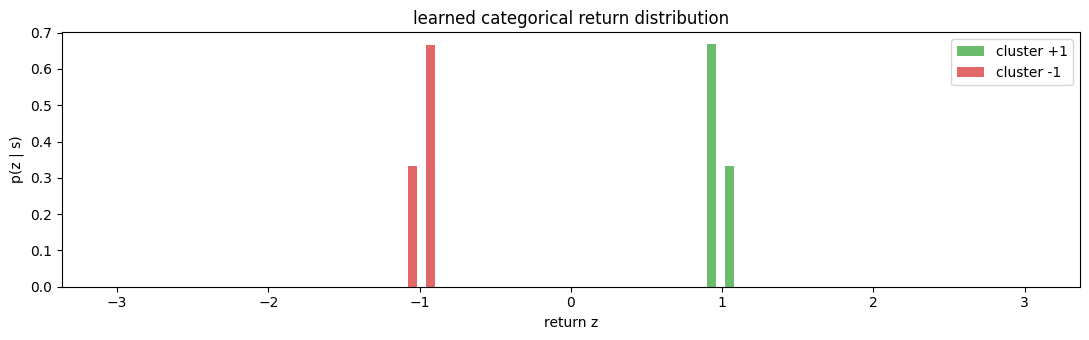

In [5]:
feats_plus = torch.tensor([[1.0, 0.0, 0.0, 0.0]])
feats_minus = torch.tensor([[0.0, 1.0, 0.0, 0.0]])
with torch.no_grad():
    p_plus = head.probs(feats_plus).squeeze(0)
    p_minus = head.probs(feats_minus).squeeze(0)

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.bar(head.support.numpy() - 0.03, p_plus.numpy(),  width=0.06, label='cluster +1', alpha=0.7, color='tab:green')
ax.bar(head.support.numpy() + 0.03, p_minus.numpy(), width=0.06, label='cluster -1', alpha=0.7, color='tab:red')
ax.set(title='learned categorical return distribution', xlabel='return z', ylabel='p(z | s)')
ax.legend(); fig.tight_layout()

## 3. Advantage conditioning end-to-end

Wire the value head + conditioner + a dummy policy into `RECAPTrainer` and run a few alternating updates.

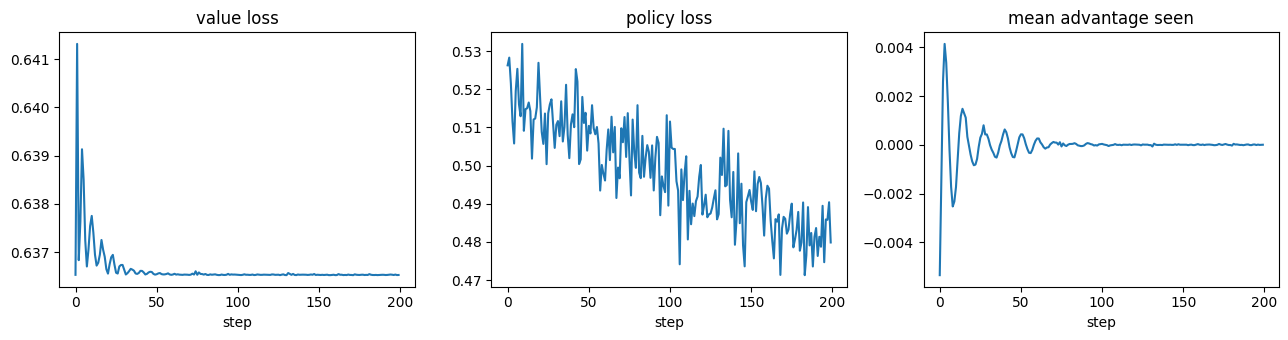

In [6]:
ACTION_DIM = 6
cond = AdvantageConditioner(cfg)
policy = nn.Linear(cfg.advantage_token_embed_dim, ACTION_DIM)

def policy_loss_fn(batch, adv_token):
    pred = policy(adv_token)
    return ((pred - batch['target_action']) ** 2).mean()

trainer = RECAPTrainer(head, cond, policy_loss_fn)

log = {'value_loss': [], 'policy_loss': [], 'mean_advantage': []}
for step in range(200):
    feats, rewards = synth_batch(B=64)
    rtg = rewards  # for terminal episodes, return-to-go == reward
    batch = {
        'state_features': feats,
        'reward': rewards,
        'next_state_features': feats,
        'done': torch.ones(feats.size(0)),
        'return_to_go': rtg,
        'target_action': 0.1 * torch.randn(feats.size(0), ACTION_DIM),
    }
    mv = trainer.update_value(batch); mp = trainer.update_policy(batch)
    for k, v in {**mv, **mp}.items():
        log.setdefault(k, []).append(v)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
axes[0].plot(log['value_loss']);     axes[0].set(title='value loss', xlabel='step')
axes[1].plot(log['policy_loss']);    axes[1].set(title='policy loss', xlabel='step')
axes[2].plot(log['mean_advantage']); axes[2].set(title='mean advantage seen', xlabel='step')
fig.tight_layout()

## 4. The deployment trick

At deployment, ask the policy for above-average behavior by feeding the *top* advantage bucket token. The model trained to imitate the actions that produced that advantage.

In [7]:
top_token = cond.top_bucket_token(batch_size=4, device=torch.device('cpu'))
with torch.no_grad():
    pred = policy(top_token)
print('top-bucket policy output shape :', pred.shape)
print('top-bucket token (first row)   :', top_token[0, :8].tolist())

top-bucket policy output shape : torch.Size([4, 6])
top-bucket token (first row)   : [1.0745246410369873, -0.34543710947036743, 1.1398591995239258, 0.6787854433059692, -1.1432385444641113, -0.8608024716377258, 1.2509105205535889, -1.090656042098999]


## Takeaways

- C51 categorical projection learns cluster-specific return distributions.
- Expected value converges to the true ±1 means.
- The conditioner + RECAPTrainer cleanly alternates value and policy steps.
- At deployment, feeding the top bucket token is how you ask for above-average behavior.